Link: https://cole-trapnell-lab.github.io/monocle3/docs/getting_started/

#### Trajectory inference

As cells move between states, they undergo a process of transcriptional re-configuration, with some genes being silenced and others newly activated.

Monocle uses an algorithm to learn the sequence of gene expression changes each cell must go through.



In [ ]:
# BiocManager::install(c("scRNAseq", 'AnnotationHub', 'scater'))

In [ ]:
# BiocManager::install(c('BiocGenerics', 'DelayedArray', 'DelayedMatrixStats',
#                        'limma', 'lme4', 'S4Vectors', 'SingleCellExperiment',
#                        'SummarizedExperiment', 'batchelor', 'HDF5Array',
#                        'ggrastr'))

In [ ]:
# remotes::install_github("bnprks/BPCells/r")

In [ ]:
# devtools::install_github('cole-trapnell-lab/monocle3')

In [1]:
library(monocle3)
library(Seurat)
library(dplyr)
library(ggplot2)
library(tidyr)
library(reshape2)

Loading required package: Biobase

Loading required package: BiocGenerics


Attaching package: 'BiocGenerics'


The following objects are masked from 'package:stats':

    IQR, mad, sd, var, xtabs


The following objects are masked from 'package:base':

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, table,
    tapply, union, unique, unsplit, which.max, which.min


Welcome to Bioconductor

    Vignettes contain introductory material; view with
    'browseVignettes()'. To cite Bioconductor, see
    'citation("Biobase")', and for packages 'citation("pkgname")'.


Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading requi

In [2]:
# Load the data
expression_matrix <- readRDS(url("https://depts.washington.edu:/trapnell-lab/software/monocle3/celegans/data/packer_embryo_expression.rds"))
cell_metadata <- readRDS(url("https://depts.washington.edu:/trapnell-lab/software/monocle3/celegans/data/packer_embryo_colData.rds"))
gene_annotation <- readRDS(url("https://depts.washington.edu:/trapnell-lab/software/monocle3/celegans/data/packer_embryo_rowData.rds"))

# Make the CDS object
cds <- new_cell_data_set(expression_matrix,
                         cell_metadata = cell_metadata,
                         gene_metadata = gene_annotation)

In [3]:
cds # C. elegans data

class: cell_data_set 
dim: 20222 6188 
metadata(1): cds_version
assays(1): counts
rownames(20222): WBGene00010957 WBGene00010958 ... WBGene00021594
  WBGene00007064
rowData names(3): id gene_short_name num_cells_expressed
colnames(6188): AAACCTGCAAGACGTG-300.1.1 AAACCTGGTGTGAATA-300.1.1 ...
  TGCGGGTAGTACTTGC-b02 TTTGTCAAGTACACCT-b02
colData names(19): cell n.umi ... bg.b01.loading bg.b02.loading
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [4]:
saveRDS(cds,file = 'monocle3_cds_raw.RDS')


  saveRDS(cds, ...) does not save annoy or hnsw nearest
  neighbor indices, which you may need for future
  analyses.



We urge you to use the function

    save_monocle_objects()

  in order to save all of the information in the cds.
  See the notes in the save_monocle_objects() help
  documentation for additional information.

However, we are running base::saveRDS() as you requested.



In [6]:
colnames(colData(cds))

[1] "cell"                "n.umi"               "time.point"         
 [4] "batch"               "Size_Factor"         "raw.embryo.time"    
 [7] "embryo.time"         "embryo.time.bin"     "raw.embryo.time.bin"
[10] "lineage"             "num_genes_expressed" "cell.type"          
[13] "bg.300.loading"      "bg.400.loading"      "bg.500.1.loading"   
[16] "bg.500.2.loading"    "bg.r17.loading"      "bg.b01.loading"     
[19] "bg.b02.loading"

In [7]:
unique(cds$cell.type)

[1] "AFD"                    NA                       "ASK_parent"            
 [4] "ASEL"                   "Neuroblast_AFD_RMD"     "Neuroblast_ADF_AWB"    
 [7] "Neuroblast_ASE_ASJ_AUA" "ASE_parent"             "Neuroblast_ASJ_AUA"    
[10] "Neuroblast_ASG_AWA"     "ADL"                    "ADL_parent"            
[13] "ASG_AWA"                "ASH"                    "ADF"                   
[16] "ASI_parent"             "AWC"                    "ADF_AWB"               
[19] "ASJ"                    "ASE"                    "AUA"                   
[22] "ASK"                    "ASI"                    "AWA"                   
[25] "AWB"                    "ASG"                    "ASER"                  
[28] "AWC_ON"

A single preprocess command performs log-normalisation, scaling and PCA analysis..

In [8]:
cds <- preprocess_cds(cds, num_dim = 100) 

Warning message:
"`qplot()` was deprecated in ggplot2 3.4.0.
ℹ The deprecated feature was likely used in the monocle3 package.
  Please report the issue to the authors."
Warning message:
"The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the monocle3 package.
  Please report the issue to the authors."


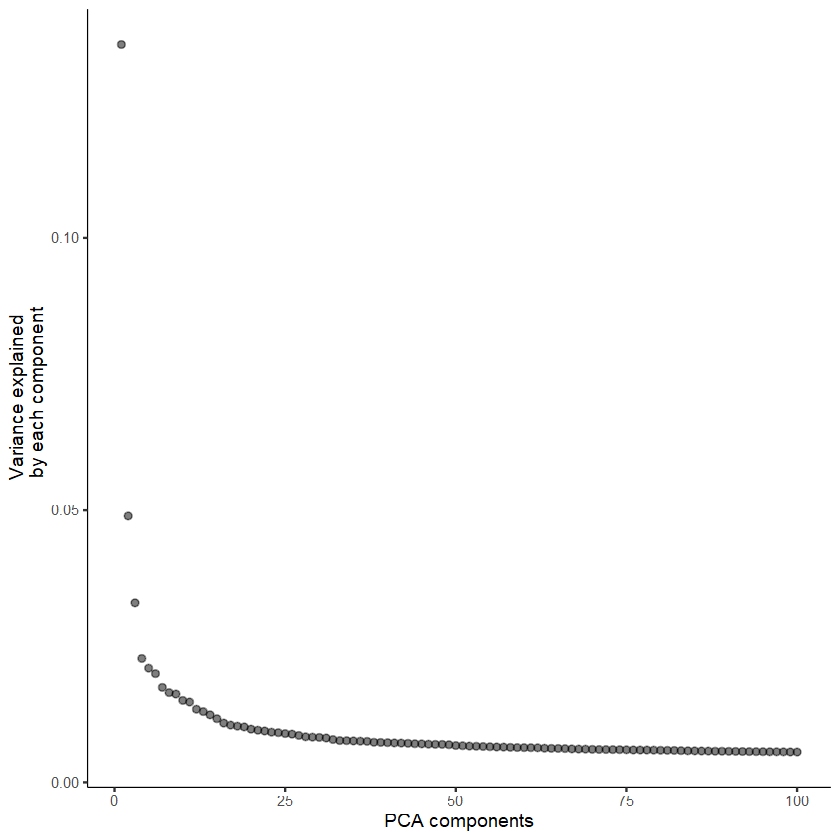

In [9]:
plot_pc_variance_explained(cds)

Around 20 dims have the highest variance explained

In [10]:
cds <- reduce_dimension(cds,cores = 8,verbose = TRUE, reduction_method = 'UMAP', max_components = 2)

No preprocess_method specified, using preprocess_method = 'PCA'

Note: reduce_dimension will produce slightly different output each time you run it unless you set 'umap.fast_sgd = FALSE' and 'cores = 1'

Running Uniform Manifold Approximation and Projection

00:09:01 UMAP embedding parameters a = 1.577 b = 0.8951

00:09:01 Read 6188 rows and found 100 numeric columns

00:09:01 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

00:09:01 Writing NN index file to temp file C:\Users\srira\AppData\Local\Temp\RtmpOCm6Ep\file2d05f6e305

00:09:01 Searching Annoy index using 8 threads, search_k = 1500

00:09:02 Annoy recall = 100%

00:09:02 Commencing smooth kNN distance calibration using 8 threads
 with target n_neighbors = 15

00:09:03 Initializing from normalized Laplacian + no

No trajectory to plot. Has learn_graph() been called yet?

cluster not found in colData(cds), cells will not be colored

cluster_cells() has not been called yet, can't color cells by cluster



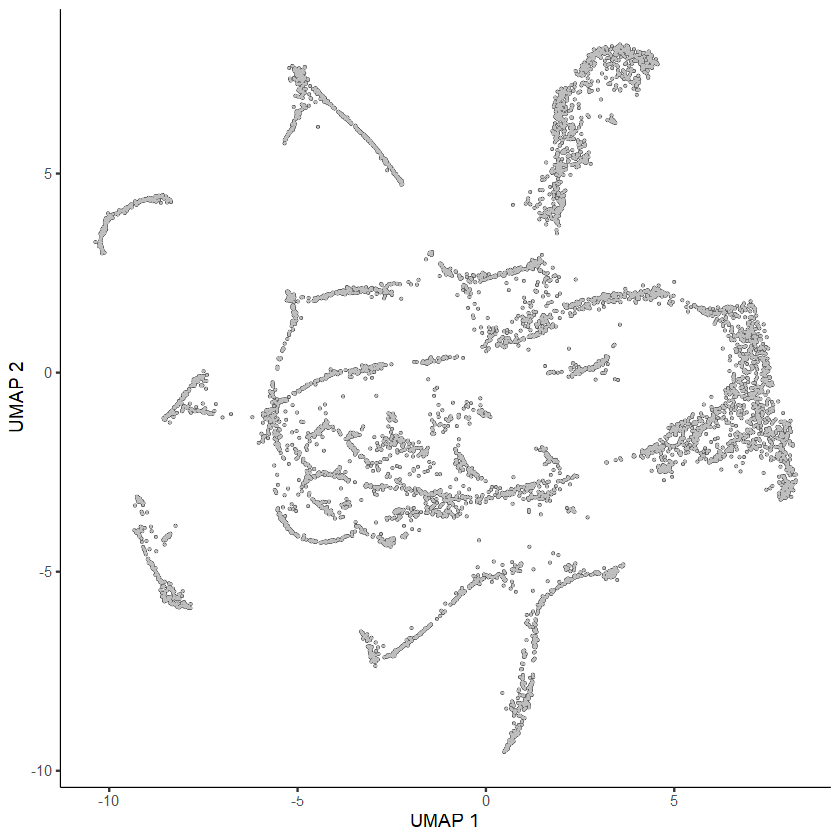

In [11]:
plot_cells(cds) # Main plotting function in Monocle3

In [ ]:
plot_cells(cds, color_cells_by="cell.type")

In [12]:
cds <- reduce_dimension(cds, reduction_method="tSNE")

No preprocess_method specified, using preprocess_method = 'PCA'



No trajectory to plot. Has learn_graph() been called yet?

Warning message:
"`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the monocle3 package.
  Please report the issue to the authors."
Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_text_repel()`)."


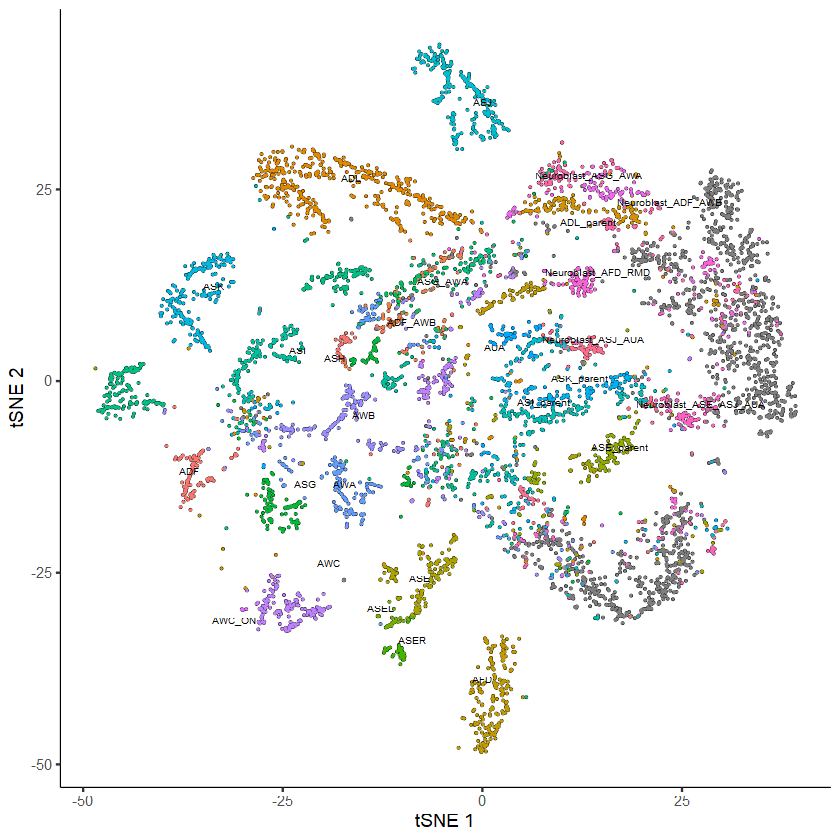

In [13]:
plot_cells(cds, reduction_method="tSNE", color_cells_by="cell.type")

No trajectory to plot. Has learn_graph() been called yet?



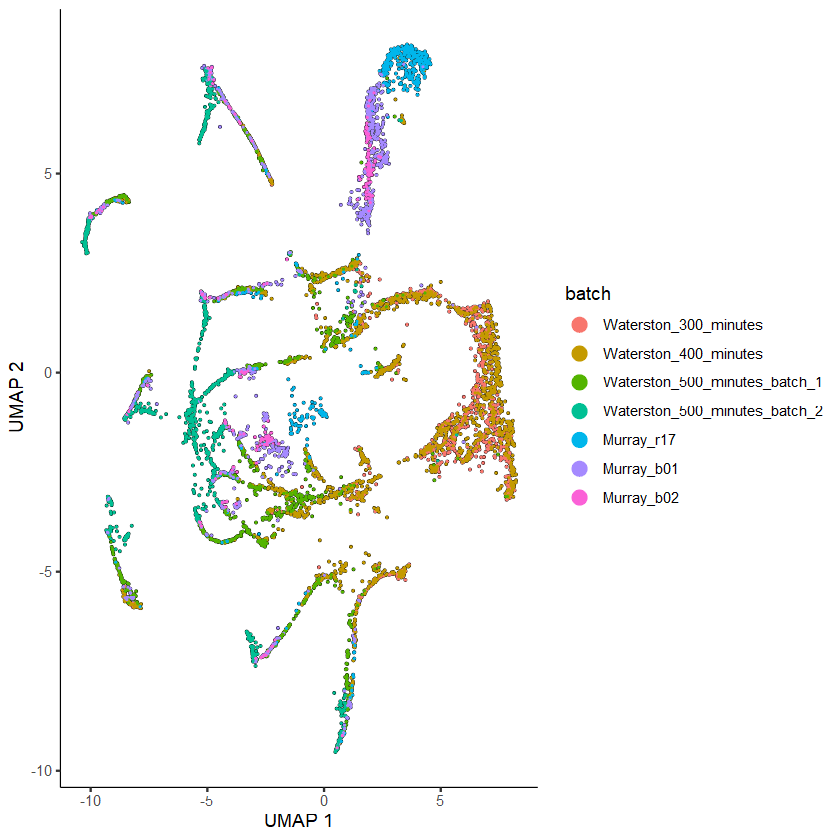

In [15]:
plot_cells(cds, color_cells_by="batch", label_cell_groups=FALSE)

Aligning cells from different batches using Batchelor.
Please remember to cite:
	 Haghverdi L, Lun ATL, Morgan MD, Marioni JC (2018). 'Batch effects in single-cell RNA-sequencing data are corrected by matching mutual nearest neighbors.' Nat. Biotechnol., 36(5), 421-427. doi: 10.1038/nbt.4091

No trajectory to plot. Has learn_graph() been called yet?



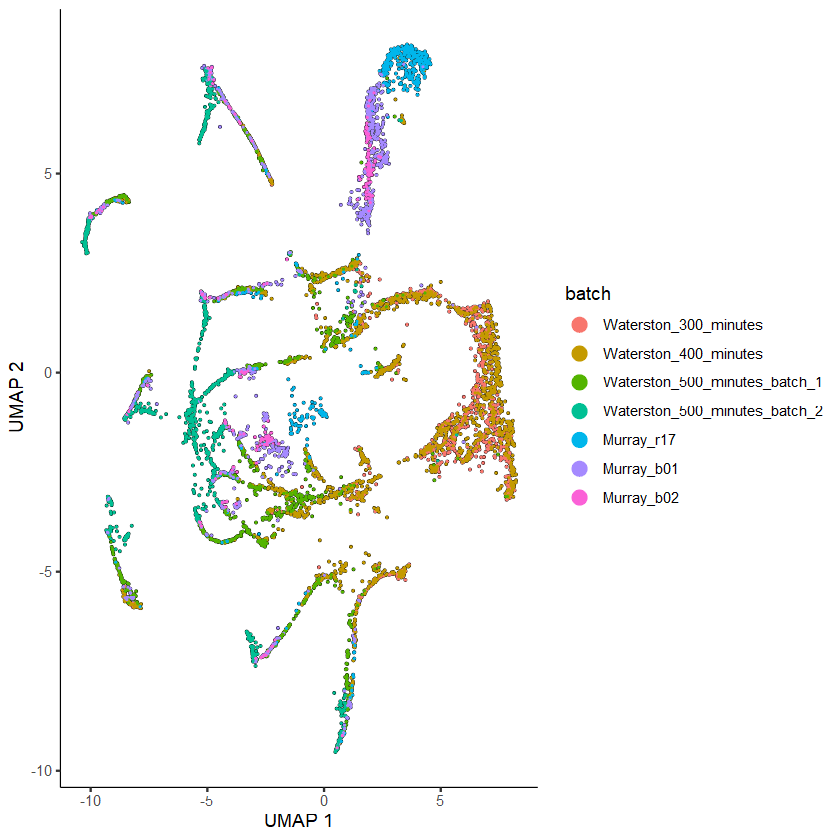

In [16]:
cds <- align_cds(cds, alignment_group = "batch", residual_model_formula_str = "~ bg.300.loading + bg.400.loading + bg.500.1.loading + bg.500.2.loading + bg.r17.loading + bg.b01.loading + bg.b02.loading")
plot_cells(cds, color_cells_by="batch", label_cell_groups=FALSE)

No trajectory to plot. Has learn_graph() been called yet?



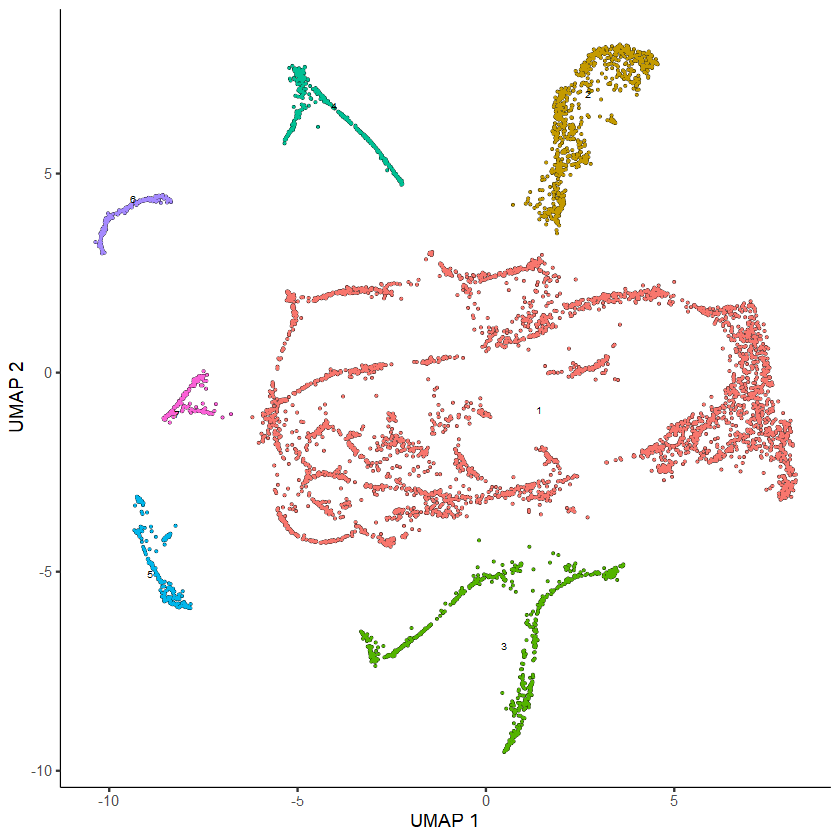

In [17]:
cds <- cluster_cells(cds, resolution=1e-5)
plot_cells(cds)

No trajectory to plot. Has learn_graph() been called yet?



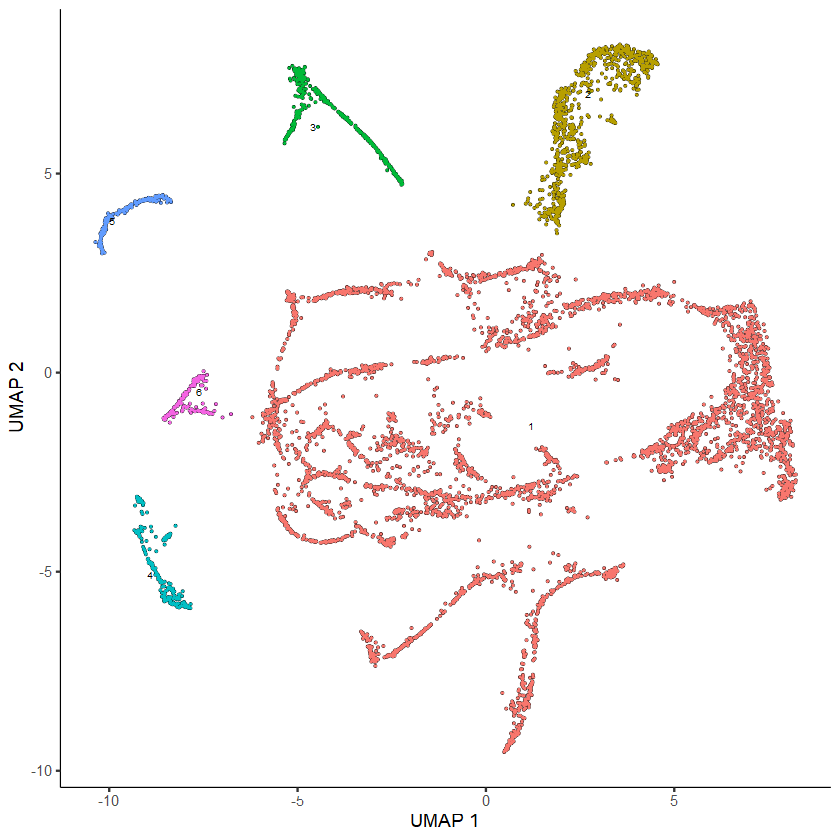

In [18]:
plot_cells(cds, color_cells_by="partition", group_cells_by="partition")

No trajectory to plot. Has learn_graph() been called yet?

Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_text_repel()`)."


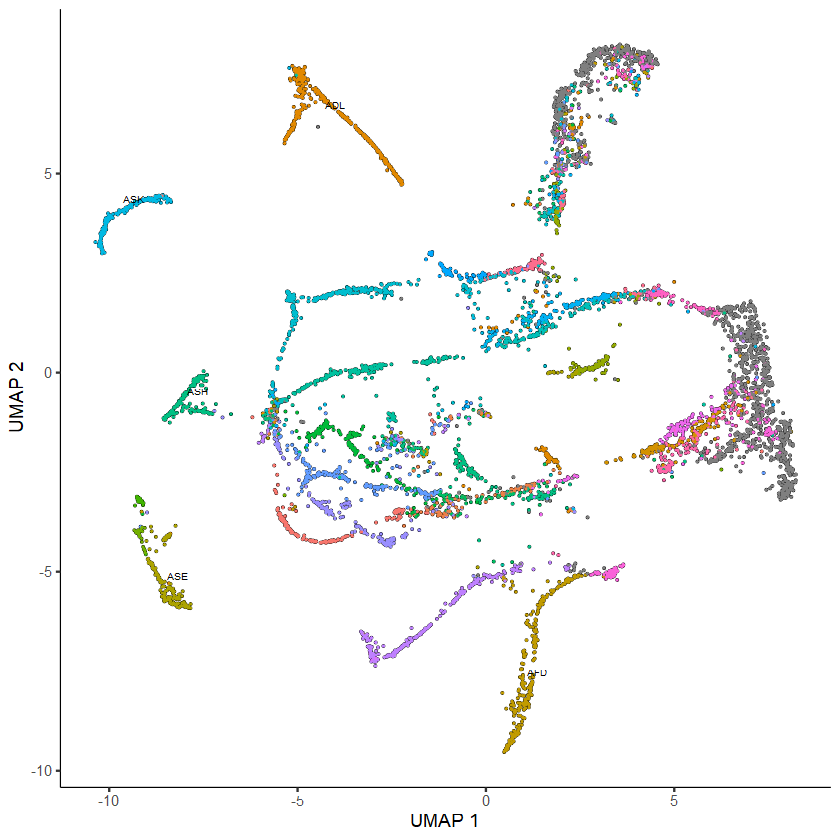

In [19]:
plot_cells(cds, color_cells_by="cell.type")

In [20]:
marker_test_res <- top_markers(cds, group_cells_by="partition", 
                               reference_cells=1000, cores=1)

  |=======================================================| 100%, Elapsed 00:07

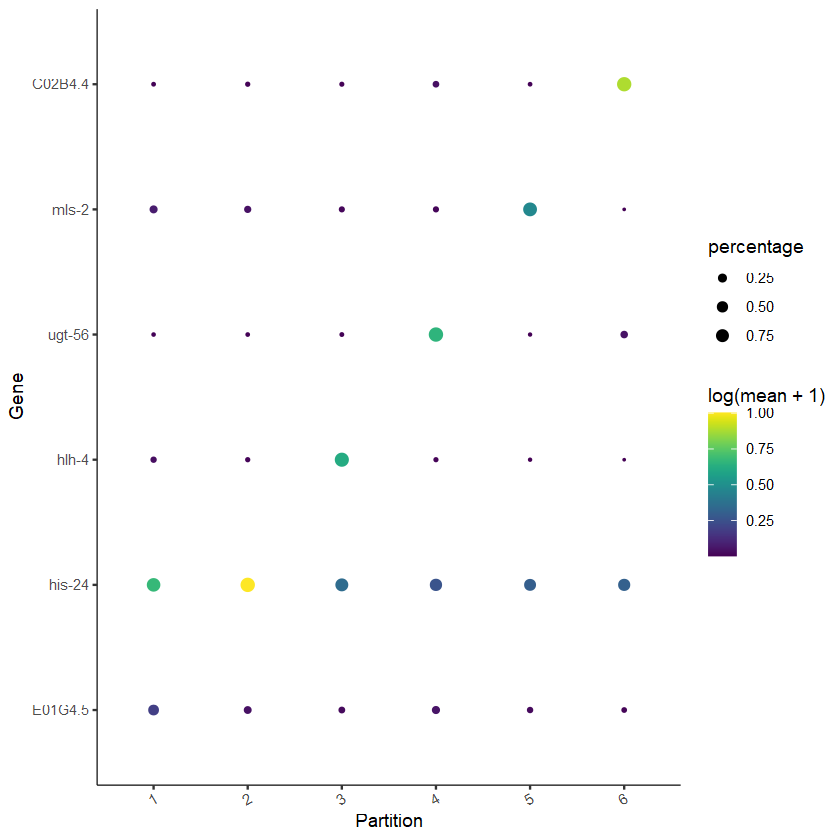

In [21]:
top_specific_markers <- marker_test_res %>%
                            filter(fraction_expressing >= 0.10) %>%
                            group_by(cell_group) %>%
                            top_n(1, pseudo_R2)

top_specific_marker_ids <- unique(top_specific_markers %>% pull(gene_id))
plot_genes_by_group(cds,
                    top_specific_marker_ids,
                    group_cells_by="partition",
                    ordering_type="maximal_on_diag",
                    max.size=3)

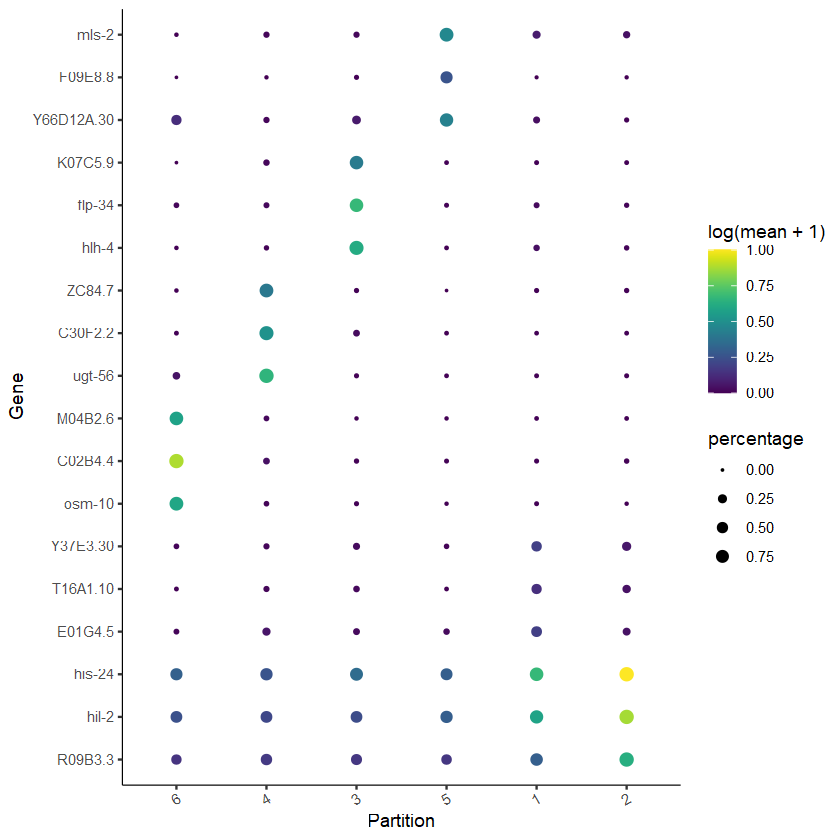

In [22]:
top_specific_markers <- marker_test_res %>%
                            filter(fraction_expressing >= 0.10) %>%
                            group_by(cell_group) %>%
                            top_n(3, pseudo_R2)

top_specific_marker_ids <- unique(top_specific_markers %>% pull(gene_id))

plot_genes_by_group(cds,
                    top_specific_marker_ids,
                    group_cells_by="partition",
                    ordering_type="cluster_row_col",
                    max.size=3)

In [23]:
str(cds)

Formal class 'cell_data_set' [package "monocle3"] with 13 slots
  ..@ reduce_dim_aux     :Formal class 'SimpleList' [package "S4Vectors"] with 4 slots
  .. .. ..@ listData       :List of 4
  .. .. .. ..$ PCA    :Formal class 'SimpleList' [package "S4Vectors"] with 4 slots
  .. .. .. .. .. ..@ listData       :List of 1
  .. .. .. .. .. .. ..$ model:Formal class 'SimpleList' [package "S4Vectors"] with 4 slots
  .. .. .. .. .. .. .. .. ..@ listData       :List of 8
  .. .. .. .. .. .. .. .. .. ..$ identity     :Formal class 'SimpleList' [package "S4Vectors"] with 4 slots
  .. .. .. .. .. .. .. .. .. .. .. ..@ listData       :List of 6
  .. .. .. .. .. .. .. .. .. .. .. .. ..$ model_type     : chr "matrix:PCA"
  .. .. .. .. .. .. .. .. .. .. .. .. ..$ model_id       :List of 2
  .. .. .. .. .. .. .. .. .. .. .. .. .. ..$ checksum: chr "6a07bf9b928957b7b18dcabd0b0ece63"
  .. .. .. .. .. .. .. .. .. .. .. .. .. ..$ dim     : int [1:2] 6188 100
  .. .. .. .. .. .. .. .. .. .. .. .. ..$ prev_m

In [24]:
cds <- learn_graph(cds)

  |======================================================================| 100%
  |======================================================================| 100%
  |======================================================================| 100%


In [25]:
colnames(colData(cds))

[1] "cell"                "n.umi"               "time.point"         
 [4] "batch"               "Size_Factor"         "raw.embryo.time"    
 [7] "embryo.time"         "embryo.time.bin"     "raw.embryo.time.bin"
[10] "lineage"             "num_genes_expressed" "cell.type"          
[13] "bg.300.loading"      "bg.400.loading"      "bg.500.1.loading"   
[16] "bg.500.2.loading"    "bg.r17.loading"      "bg.b01.loading"     
[19] "bg.b02.loading"

Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the monocle3 package.
  Please report the issue to the authors."
Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_text_repel()`)."


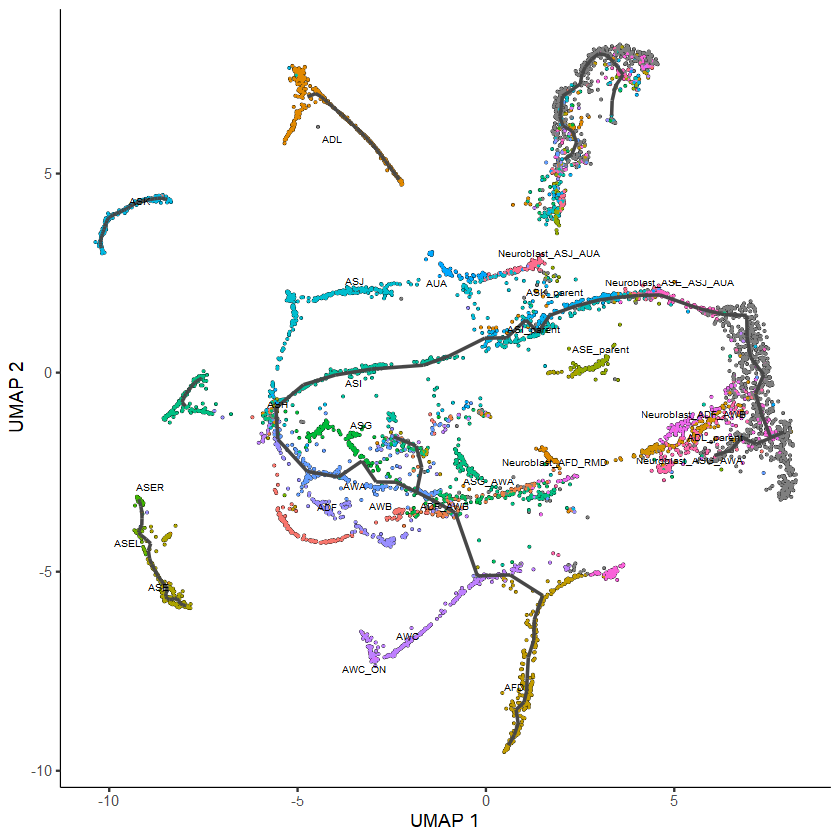

In [27]:
plot_cells(cds,
           color_cells_by = "cell.type",
           label_groups_by_cluster=FALSE,
           label_leaves=FALSE,
           label_branch_points=FALSE)

In [28]:
get_earliest_principal_node <- function(cds, time_bin="130-170"){
  cell_ids <- which(colData(cds)[, "embryo.time.bin"] == time_bin)

  closest_vertex <-
  cds@principal_graph_aux[["UMAP"]]$pr_graph_cell_proj_closest_vertex
  closest_vertex <- as.matrix(closest_vertex[colnames(cds), ])
  root_pr_nodes <-
    igraph::V(principal_graph(cds)[["UMAP"]])$name[as.numeric(names
   (which.max(table(closest_vertex[cell_ids,]))))]

  root_pr_nodes
}
# cds <- order_cells(cds, root_pr_nodes=get_earliest_principal_node(cds))

In [30]:
root_nodes=get_earliest_principal_node(cds)

In [31]:
root_nodes

[1] "Y_74"

In [32]:
cds <- order_cells(cds = cds, root_pr_nodes = root_nodes)

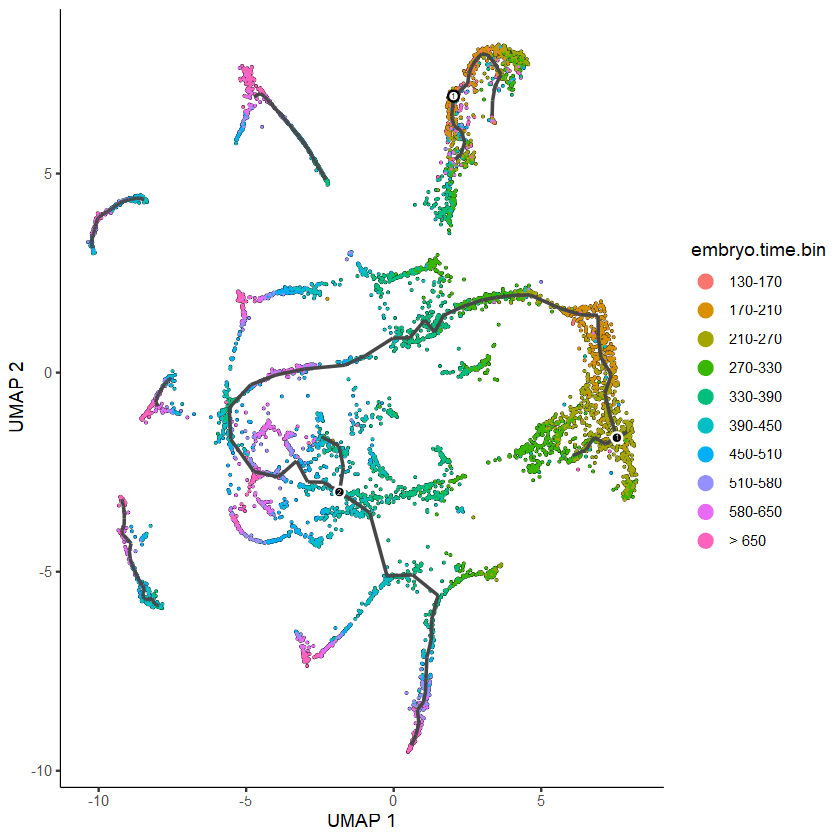

In [41]:
plot_cells(cds,
           color_cells_by = "embryo.time.bin",
           label_cell_groups=FALSE,
           label_leaves=FALSE,
           label_branch_points=TRUE,
           graph_label_size=1.5)

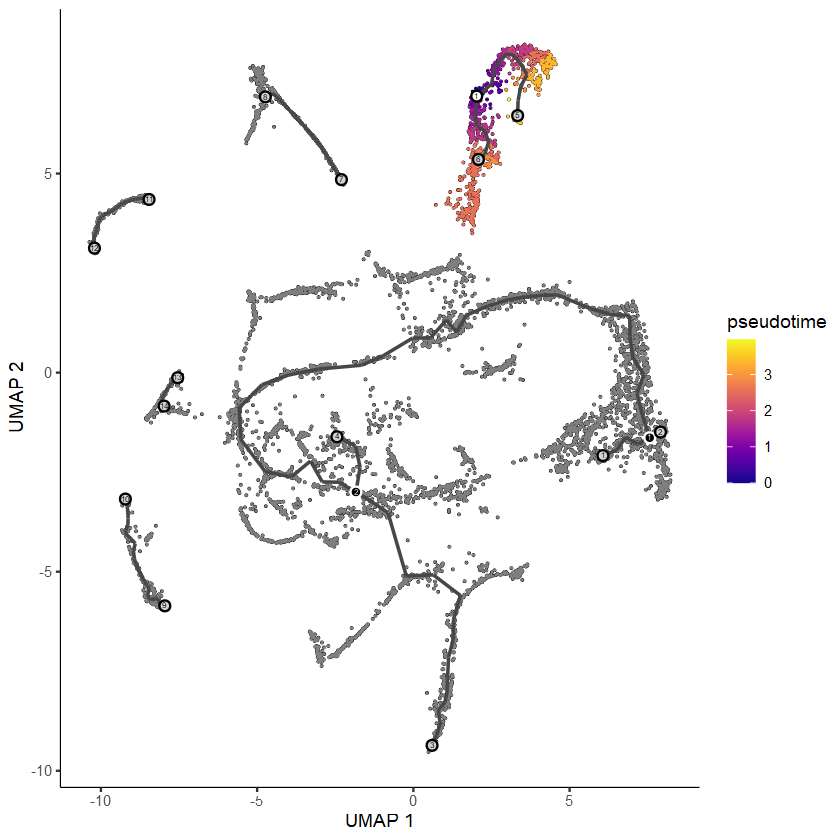

In [43]:
plot_cells(cds,
           color_cells_by = "pseudotime",
           label_cell_groups=FALSE,
           label_leaves=TRUE,
           label_branch_points=TRUE,
           graph_label_size=1.5)

In [44]:
saveRDS(cds, file = 'cds_monocle3_data_pseudotimes.RDS')


  saveRDS(cds, ...) does not save annoy or hnsw nearest
  neighbor indices, which you may need for future
  analyses.



We urge you to use the function

    save_monocle_objects()

  in order to save all of the information in the cds.
  See the notes in the save_monocle_objects() help
  documentation for additional information.

However, we are running base::saveRDS() as you requested.



In [54]:
ciliated_cds_pr_test_res <- graph_test(cds, neighbor_graph="principal_graph", cores=4)
pr_deg_ids <- row.names(subset(ciliated_cds_pr_test_res, q_value < 0.05))

Warning message in pbmcapply::pbmclapply(row.names(exprs_mat), FUN = function(x, :
"mc.cores > 1 is not supported on Windows due to limitation of mc*apply() functions.
  mc.core is set to 1."


  |=======================================================| 100%, Elapsed 06:45

In [64]:
length(pr_deg_ids)

[1] 9162

In [65]:
dim(ciliated_cds_pr_test_res)

[1] 20222     8

In [68]:
head(ciliated_cds_pr_test_res)

,status,p_value,morans_test_statistic,morans_I,id,gene_short_name,num_cells_expressed,q_value
,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<int>,<dbl>
WBGene00010957,OK,0.000000e+00,44.83184,0.16157069,WBGene00010957,nduo-6,6038,0.000000e+00
WBGene00010958,OK,2.539356e-173,28.04145,0.10105131,WBGene00010958,ndfl-4,1597,1.950963e-172
WBGene00010959,OK,4.650910e-54,15.43650,0.05555209,WBGene00010959,nduo-1,5342,2.260130e-53
WBGene00010960,OK,0.000000e+00,46.35734,0.16710951,WBGene00010960,atp-6,5921,0.000000e+00
WBGene00010961,OK,2.172861e-54,15.48551,0.05573910,WBGene00010961,nduo-2,2686,1.059728e-53
WBGene00000829,OK,1.452407e-89,20.03188,0.07214287,WBGene00000829,ctb-1,5079,8.533152e-89


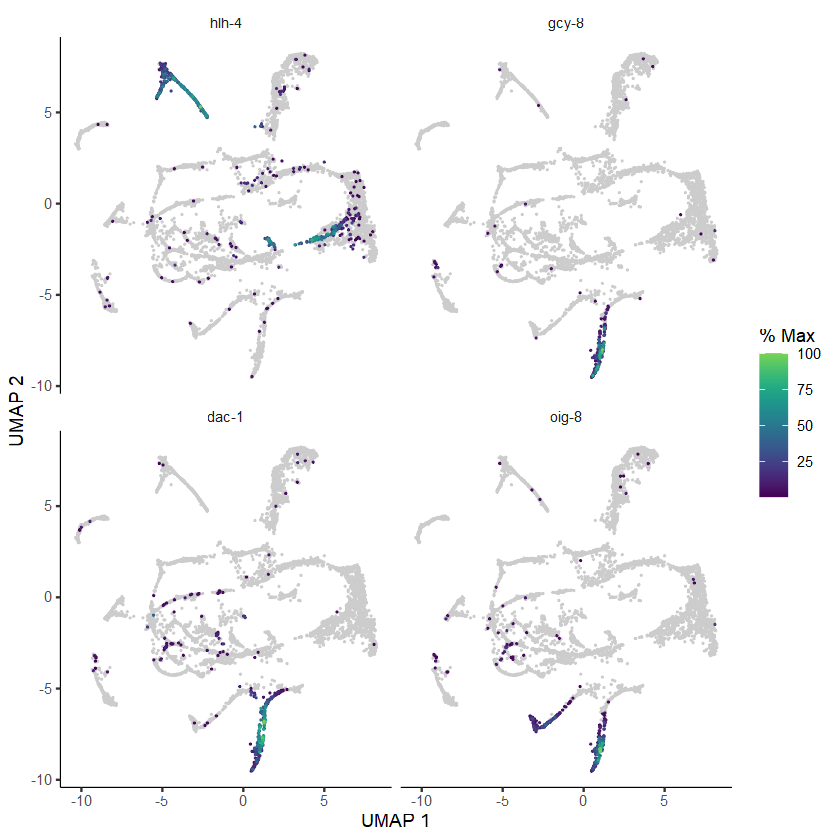

In [55]:
plot_cells(cds, genes=c("hlh-4", "gcy-8", "dac-1", "oig-8"),
           show_trajectory_graph=FALSE,
           label_cell_groups=FALSE,
           label_leaves=FALSE)

In [56]:
gene_module_df <- find_gene_modules(cds[pr_deg_ids,], resolution=c(10^seq(-6,-1)))

In [57]:
head(gene_module_df)

id,module,supermodule,dim_1,dim_2
<chr>,<fct>,<fct>,<dbl>,<dbl>
WBGene00010957,4,1,-5.129500,0.8546296
WBGene00010958,4,1,-5.391806,0.9032454
WBGene00010959,4,1,-5.166798,0.8548170
WBGene00010960,4,1,-5.153748,0.9023158
WBGene00010961,4,1,-5.197619,0.9180053
WBGene00000829,4,1,-5.147279,0.8878204


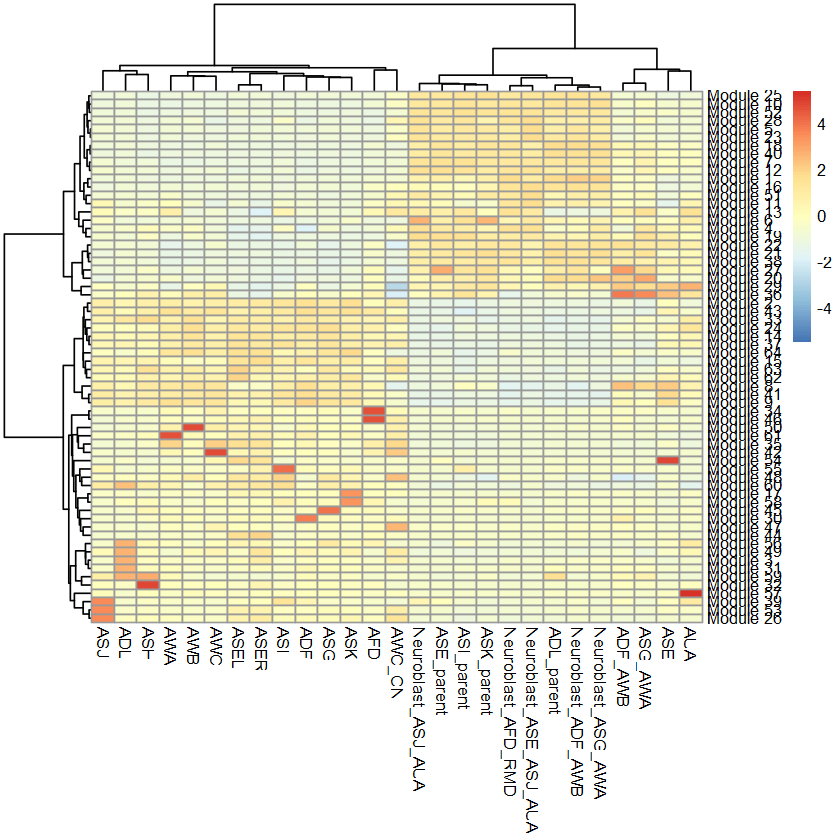

In [58]:
cell_group_df <- tibble::tibble(cell=row.names(colData(cds)), 
                                cell_group=colData(cds)$cell.type)
agg_mat <- aggregate_gene_expression(cds, gene_module_df, cell_group_df)
row.names(agg_mat) <- stringr::str_c("Module ", row.names(agg_mat))
pheatmap::pheatmap(agg_mat,
                   scale="column", clustering_method="ward.D2")

In [69]:
significant_genes <- ciliated_cds_pr_test_res %>%
  dplyr::arrange(q_value) %>%
  dplyr::filter(q_value < 0.01) # You can adjust this threshold

# View the top 10 most significant genes
head(significant_genes, 10)

,status,p_value,morans_test_statistic,morans_I,id,gene_short_name,num_cells_expressed,q_value
,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<int>,<dbl>
WBGene00010957,OK,0,44.83184,0.1615707,WBGene00010957,nduo-6,6038,0
WBGene00010960,OK,0,46.35734,0.1671095,WBGene00010960,atp-6,5921,0
WBGene00010962,OK,0,68.55653,0.2472145,WBGene00010962,ctc-3,5885,0
WBGene00010965,OK,0,44.67834,0.1610389,WBGene00010965,ctc-2,5914,0
WBGene00021396,OK,0,118.03869,0.4255535,WBGene00021396,cutl-24,508,0
WBGene00006561,OK,0,39.25728,0.1415109,WBGene00006561,tcl-2,1054,0
WBGene00021395,OK,0,113.88555,0.4109039,WBGene00021395,pnc-1,1637,0
WBGene00017576,OK,0,44.23642,0.1589799,WBGene00017576,cdh-8,155,0
WBGene00015996,OK,0,72.29624,0.2516055,WBGene00015996,C18H7.6,18,0


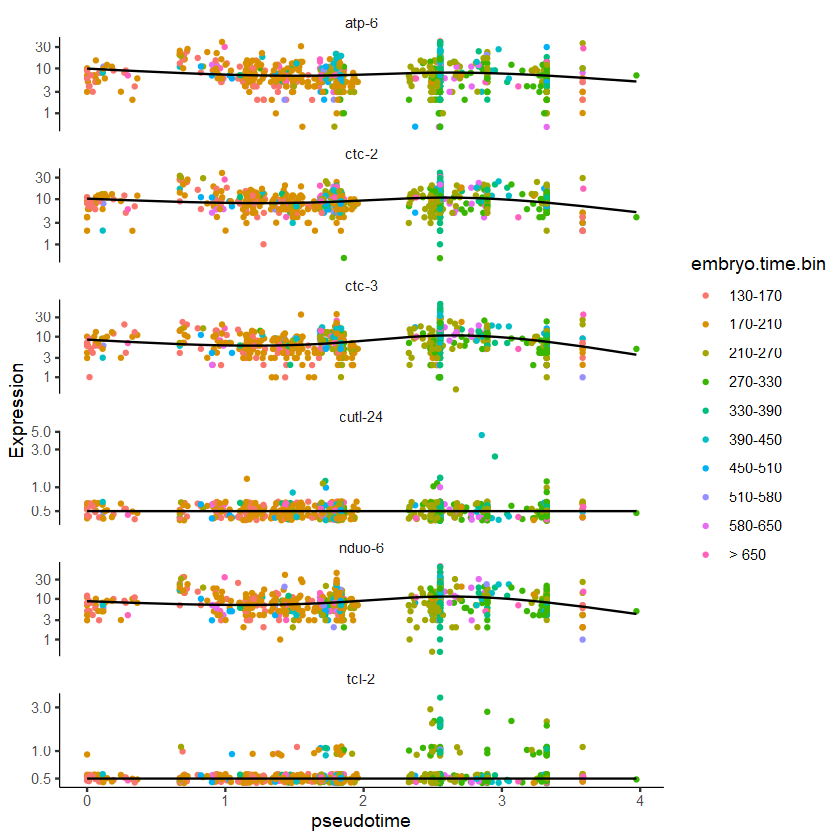

In [71]:
top_genes_to_plot <- significant_genes %>%
  dplyr::pull(gene_short_name) %>%
  head(6)

# Step 2: Now, use that vector in the plot_genes_in_pseudotime function.
# Notice there is no pipe (%>%) before this command.
plot_genes_in_pseudotime(cds[rowData(cds)$gene_short_name %in% top_genes_to_plot, ],
                         color_cells_by = "embryo.time.bin",
                         min_expr = 0.5)

In [72]:
saveRDS(object=cds, file='cds_demo_trajectory.RDS')


  saveRDS(cds, ...) does not save annoy or hnsw nearest
  neighbor indices, which you may need for future
  analyses.





We urge you to use the function

    save_monocle_objects()

  in order to save all of the information in the cds.
  See the notes in the save_monocle_objects() help
  documentation for additional information.

However, we are running base::saveRDS() as you requested.

